# Global sensitivity analysis: Mass-action kinetics, double binding 

Nathaniel Linden (UCSD MAE) - March  2023

In [66]:
import sunode
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import sympy as sym
from SALib.sample import sobol as sobol_samp
from SALib.sample import morris as morris_samp
from SALib.analyze import sobol as sobol_analyze
from SALib.analyze import morris as morris_analyze
from SALib.analyze.hdmr import analyze as hdmr_analyze
import sys
import time
import multiprocessing
from tqdm import tqdm
from joblib import Parallel, delayed
sys.path.insert(0, '../odes')

import ampk_MA_double_mech as model1
%matplotlib inline
plt.style.use('~/.matplotlib/custom.mplstyle')
mpl.rcParams['figure.autolayout'] = True
plt.rcParams['text.usetex'] = False
mpl.rcParams['text.usetex'] = False
# plt.rcParams['mathtext.fontset']='dejavusans'

In [ ]:
# load the results from GSA sampling


First, we want to plot how well the steady-state checking algorithm is working...

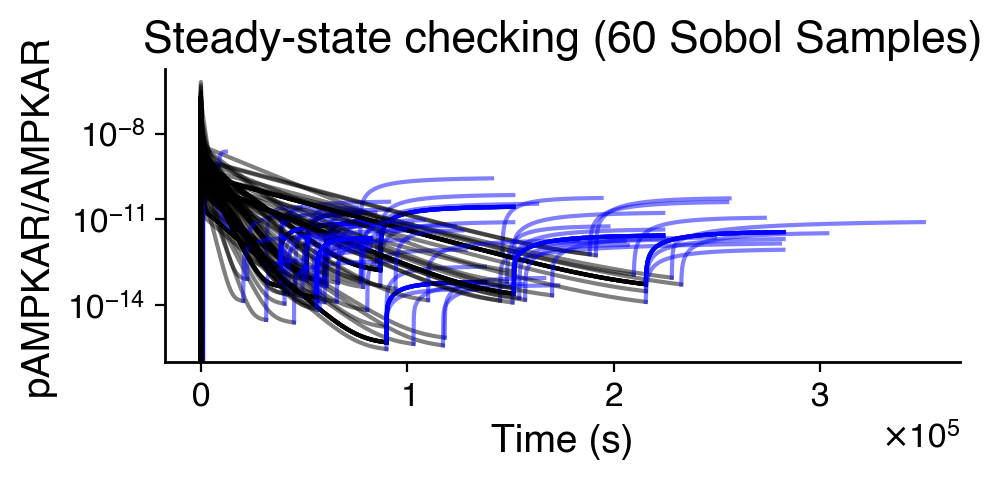

In [93]:
fig, ax = plt.subplots(2,1, figsize=(5,5))
for a in sols_sobol_corr:
    ax[0].plot(a[3], a[1].view(problem_ode.state_dtype)['pAMPKAR']/a[1].view(problem_ode.state_dtype)['AMPKAR'],
            'k', alpha=0.5)
    ax[0].plot(1+a[3][-1]+a[4], a[2].view(problem_ode.state_dtype)['pAMPKAR']/a[2].view(problem_ode.state_dtype)['AMPKAR'],
            'b', alpha=0.5)
ax.set_yscale('log')
ax.set_xlabel('Time (s)')
ax.set_ylabel('pAMPKAR/AMPKAR')
ax.set_title('Steady-state checking (60 Sobol Samples)')
fig.savefig('sobol_corr_ss_check.pdf')

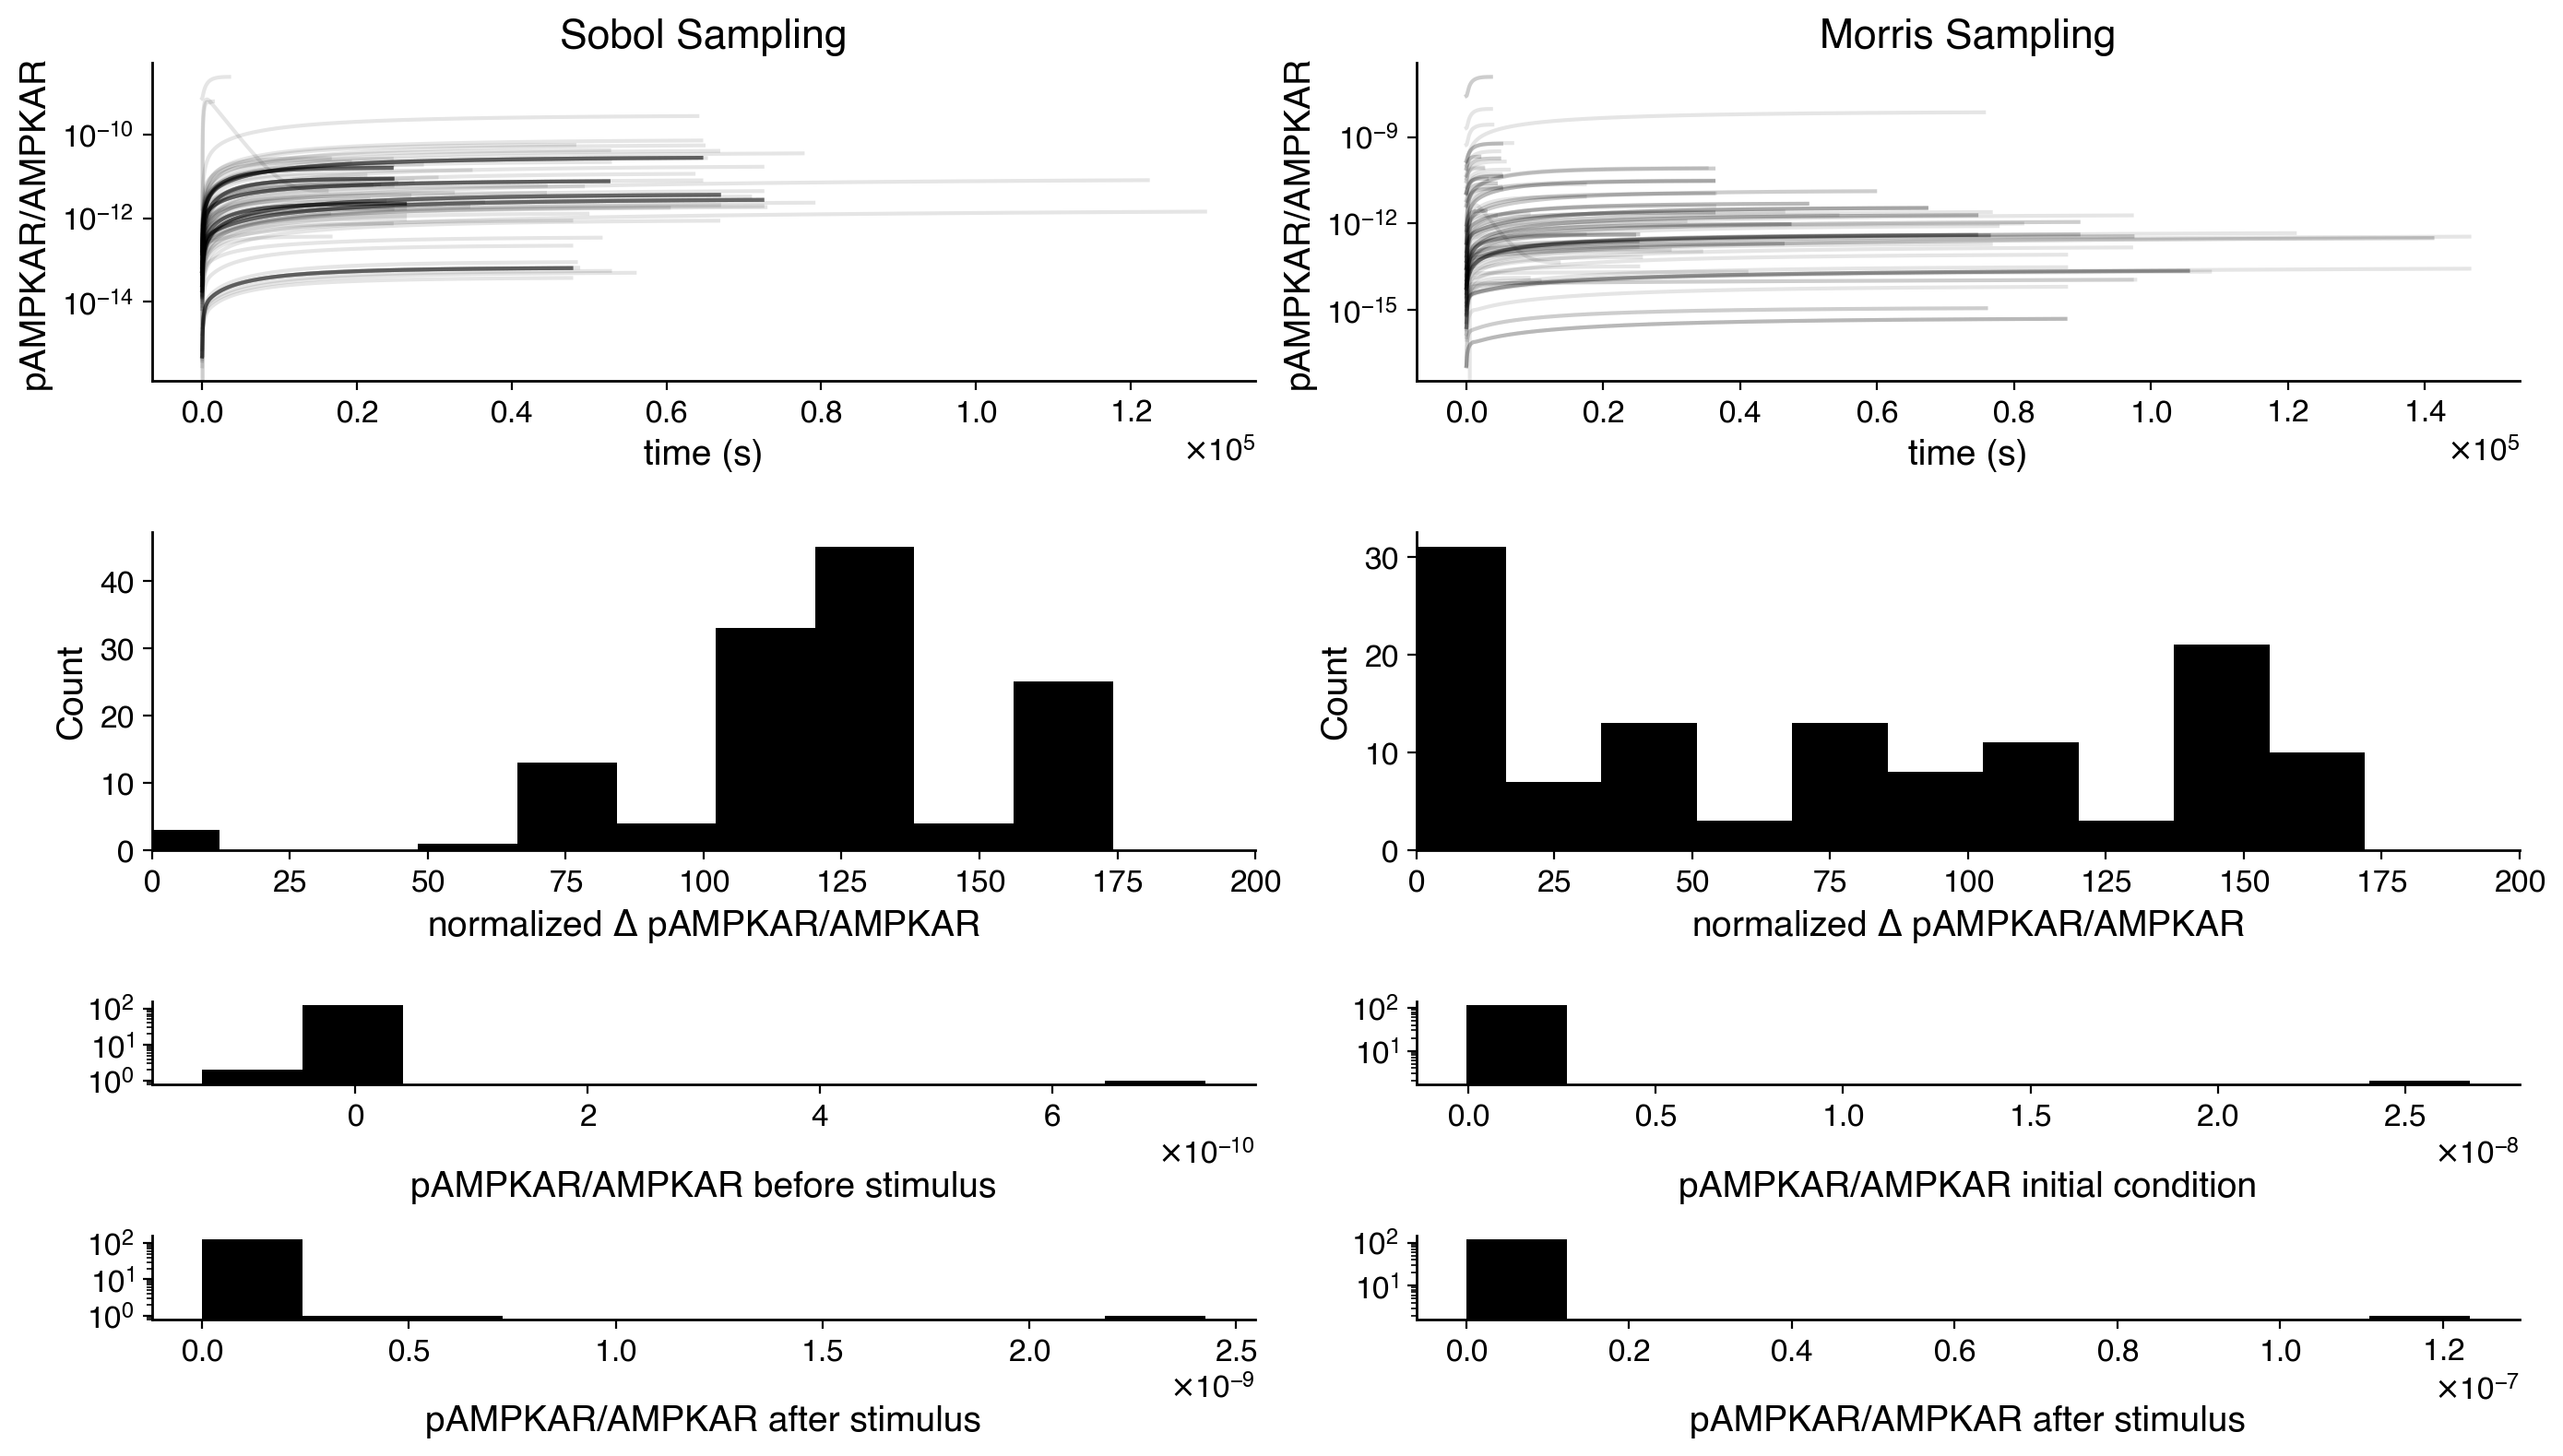

In [94]:
# plot the solutions
# fig, ax = plt.subplots(3, 2, figsize=(10,10))
# f, (a0, a1) = plt.subplots(1, 2, height_ratios=[3, 1])
fig, ax = plt.subplot_mosaic(
    [['traj A', 'traj B'],
     ['traj A', 'traj B'],
     ['hist A', 'hist B'],
     ['hist A', 'hist B'],
     ['hist C', 'hist D'],
     ['hist E', 'hist F']],figsize=(14,8))
for sol in sols_sobol_corr:
    ax['traj A'].plot(sol[4], sol[2].view(problem_ode.state_dtype)['pAMPKAR']/sol[2].view(problem_ode.state_dtype)['AMPKAR'], color='k', alpha=0.1)
ax['hist A'].hist(np.array([sol[0][1] for sol in sols_sobol_corr]), color='k')
ax['hist C'].hist(np.array([sol[0][0] for sol in sols_sobol_corr]), color='k')
ax['hist E'].hist(np.array([sol[0][1]*sol[0][0]+sol[0][0] for sol in sols_sobol_corr]), color='k')

    

for sol in sols_morris_corr:
    ax['traj B'].plot(sol[4], sol[2].view(problem_ode.state_dtype)['pAMPKAR']/sol[2].view(problem_ode.state_dtype)['AMPKAR'], color='k', alpha=0.1)
ax['hist B'].hist(np.array([sol[0][1] for sol in sols_morris_corr]), color='k')
ax['hist D'].hist(np.array([sol[0][0] for sol in sols_morris_corr]), color='k')
ax['hist F'].hist(np.array([sol[0][1]*sol[0][0]+sol[0][0] for sol in sols_morris_corr]), color='k')


# plot formatting
ax['traj A'].set_xlabel('time (s)')
ax['traj A'].set_ylabel('pAMPKAR/AMPKAR')
ax['traj A'].set_title('Sobol Sampling')
ax['traj A'].set_yscale('log')

ax['hist A'].set_xlabel('normalized $\Delta$ pAMPKAR/AMPKAR')
ax['hist A'].set_ylabel('Count')
ax['hist A'].set_xlim([0.0, 200.0])

ax['hist C'].set_xlabel('pAMPKAR/AMPKAR before stimulus', labelpad=15)
ax['hist C'].set_yscale('log')

ax['hist E'].set_xlabel('pAMPKAR/AMPKAR after stimulus', labelpad=15)
ax['hist E'].set_yscale('log')

ax['traj B'].set_xlabel('time (s)')
ax['traj B'].set_ylabel('pAMPKAR/AMPKAR')
ax['traj B'].set_title('Morris Sampling')
ax['traj B'].set_yscale('log')

ax['hist B'].set_xlabel('normalized $\Delta$ pAMPKAR/AMPKAR')
ax['hist B'].set_ylabel('Count')
ax['hist B'].set_xlim([0.0, 200.0])

ax['hist D'].set_xlabel('pAMPKAR/AMPKAR initial condition', labelpad=15)
ax['hist D'].set_yscale('log')

ax['hist F'].set_xlabel('pAMPKAR/AMPKAR after stimulus', labelpad=15)
ax['hist F'].set_yscale('log')
fig.savefig('./MA_double_mech/bounds_test.pdf')

### Now generate more samples for the actual analysis

In [ ]:
# generate samples using the Saltelli and Morris sampling methods
# START with a small number of samples
nsamps = 1024
# uncorrelated
param_vals_sobol_MA = sobol_samp.sample(problem_MA_90, nsamps, calc_second_order=False, seed=seed)
param_vals_morris_MA = morris_samp.sample(problem_MA_90, nsamps, seed=seed)
param_vals_sobol_MM = sobol_samp.sample(problem_MM_90, nsamps, calc_second_order=False, seed=seed)
param_vals_morris_MM = morris_samp.sample(problem_MM_90, nsamps, seed=seed)

# correlated
# copy MA to np arrays
param_vals_sobol_MA_corr = np.array(param_vals_sobol_MA)
param_vals_morris_MA_corr = np.array(param_vals_morris_MA)
param_vals_sobol_MM_np = np.array(param_vals_sobol_MM)
param_vals_morris_MM_np = np.array(param_vals_morris_MM)

# now compute all kons using samples of Km and from the MM model and Kcat from MA model
kcat_idxs_MA = [4,6,8,10,12]
kon_idxs_MA = [3,5,7,9,11]
km_idxs_MM = [4,6,8,10,12]
for kcat_i, kon_i, km_i in zip(kcat_idxs_MA, kon_idxs_MA, km_idxs_MM):
    param_vals_sobol_MA_corr[:,kon_i] = (1+param_vals_sobol_MA_corr[:,kcat_i])/param_vals_sobol_MM_np[:,km_i]
for kcat_i, kon_i, km_i in zip(kcat_idxs_MA, kon_idxs_MA, km_idxs_MM):  
    param_vals_morris_MA_corr[:,kon_i] = (1+param_vals_morris_MA_corr[:,kcat_i])/param_vals_morris_MM_np[:,km_i]

### Now run the model with the samples

In [ ]:
# now run the model with the Sobol set of samples
tstart = time.time()
sobol_outputs = [single_model_eval(p_set, problem_ode, 
                      solver, set_init_conds(problem_ode, state_names), 
                      tvals, state_names)[0] for p_set in param_vals_sobol_MA]
tend = time.time()
print('Simulating the {} Sobol parameter sets took {} seconds'.format(param_vals_sobol_MA.shape[0], tend-tstart))

np.save('./MA_double_mech/20230407_GSA_MA_double_mech_sobol_samples', np.array(sobol_outputs))
# sobol_outputs = np.load('./MA_double_mech/20230320_GSA_MA_double_mech_sobol_samples.npy')

Simulating the 163840 Sobol parameter sets took 4290.120934009552 seconds


In [ ]:
# now run the model with the correlated Sobol set of samples
tstart = time.time()
sobol_outputs_corr = [single_model_eval(p_set, problem_ode, 
                      solver, set_init_conds(problem_ode, state_names), 
                      tvals, state_names)[0] for p_set in param_vals_sobol_MA_corr]
tend = time.time()
print('Simulating the {} Sobol parameter sets took {} seconds'.format(param_vals_sobol_MA_corr.shape[0], tend-tstart))

np.save('./MA_double_mech/20230407_GSA_MA_double_mech_sobol_samples_corr', np.array(sobol_outputs))

In [ ]:
# And the Morris set of samples
tstart = time.time()
morris_outputs = [single_model_eval(p_set, problem_ode, 
                      solver, set_init_conds(problem_ode, state_names), 
                      tvals, state_names)[0] for p_set in param_vals_morris_MA]
tend = time.time()
print('Simulating the {} Morris parameter sets took {} seconds'.format(param_vals_morris_MA.shape[0], tend-tstart))

np.save('./MA_double_mech/20230407_GSA_MA_double_mech_morris_samples', np.array(morris_outputs))
# morris_outputs = np.load('./MA_double_mech/20230320_GSA_MA_double_mech_morris_samples.npy')

Simulating the 81920 Morris parameter sets took 1044.4503779411316 seconds


In [ ]:
# And the Morris set of samples
tstart = time.time()
morris_outputs_corr = [single_model_eval(p_set, problem_ode, 
                      solver, set_init_conds(problem_ode, state_names), 
                      tvals, state_names)[0] for p_set in param_vals_morris_MA_corr]
tend = time.time()
print('Simulating the {} Morris parameter sets took {} seconds'.format(param_vals_morris_MA_corr.shape[0], tend-tstart))

np.save('./MA_double_mech/20230407_GSA_MA_double_mech_morris_samples', np.array(morris_outputs))
# morris_outputs = np.load('./MA_double_mech/20230320_GSA_MA_double_mech_morris_samples.npy')

### Compute relevant sensitivity indices

In [ ]:
# convert lists to numpy arrays and remove extra dimension
m_outputs_np = np.squeeze(np.array(morris_outputs))
s_outputs_np = np.squeeze(np.array(sobol_outputs))
m_outputs_corr_np = np.squeeze(np.array(morris_outputs_corr))
s_outputs_corr_np = np.squeeze(np.array(sobol_outputs_corr))

# compute Sobol and Morris indices
Si_morris_ss = morris_analyze.analyze(problem_90, param_vals_morris, m_outputs_np[:,0])
Si_morris_delta = morris_analyze.analyze(problem_90, param_vals_morris, m_outputs_np[:,1])
Si_sobol_ss = sobol_analyze.analyze(problem_90, s_outputs_np[:,0], calc_second_order=True)
Si_sobol_delta = sobol_analyze.analyze(problem_90, s_outputs_np[:,1], calc_second_order=True)

# compute HDMR indices


In [ ]:
# sort sobol indices by ST
dtype = [('name', 'U10'), ('S1', float), ('S1_conf', float), ('ST', float), ('ST_conf', float)]

Si_sobol_ss_sorted = np.array([(name, S1, S1_conf, ST, ST_conf) for 
                               name, S1, S1_conf, ST, ST_conf in zip(param_names, Si_sobol_ss['S1'], Si_sobol_ss['S1_conf'], 
                                                                     Si_sobol_ss['ST'], Si_sobol_ss['ST'])], dtype=dtype)
Si_sobol_ss_sorted = np.sort(Si_sobol_ss_sorted, order='S1')[::-1]

Si_sobol_delta_sorted = np.array([(name, S1, S1_conf, ST, ST_conf) for 
                               name, S1, S1_conf, ST, ST_conf in zip(param_names, Si_sobol_delta['S1'], Si_sobol_delta['S1_conf'], 
                                                                     Si_sobol_delta['ST'], Si_sobol_delta['ST'])], dtype=dtype)
Si_sobol_delta_sorted = np.sort(Si_sobol_delta_sorted, order='S1')[::-1]

# sort Morris indices by mu_star
dtype = [('name', 'S10'), ('mu_star', float), ('sigma', float), ('mu', float), ('mu_star_conf', float)]

Si_morris_ss_sorted = np.array([(name, mu_star, sigma, mu, mu_star_conf) for 
                               name, mu_star, sigma, mu, mu_star_conf in zip(param_names, Si_morris_ss['mu_star'], Si_morris_ss['sigma'], 
                                                                     Si_morris_ss['mu'], Si_morris_ss['mu_star_conf'])], dtype=dtype)
Si_morris_ss_sorted = np.sort(Si_morris_ss_sorted, order='mu_star')

Si_morris_delta_sorted = np.array([(name, mu_star, sigma, mu, mu_star_conf) for 
                               name, mu_star, sigma, mu, mu_star_conf in zip(param_names, Si_morris_delta['mu_star'], Si_morris_delta['sigma'], 
                                                                     Si_morris_delta['mu'], Si_morris_delta['mu_star_conf'])], dtype=dtype)
Si_morris_delta_sorted = np.sort(Si_morris_delta_sorted, order='mu_star')

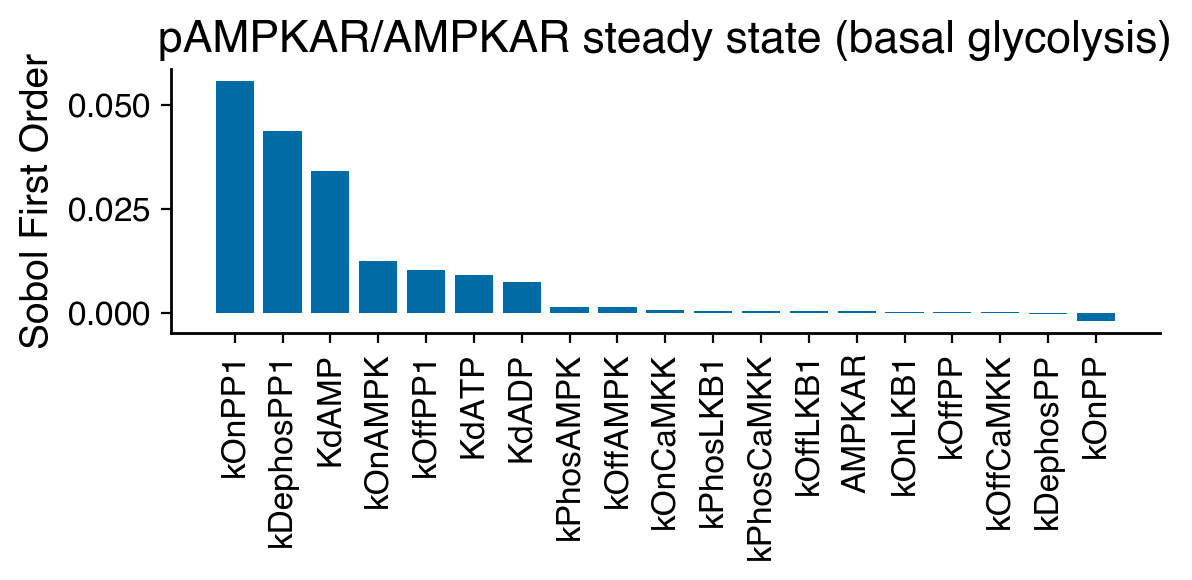

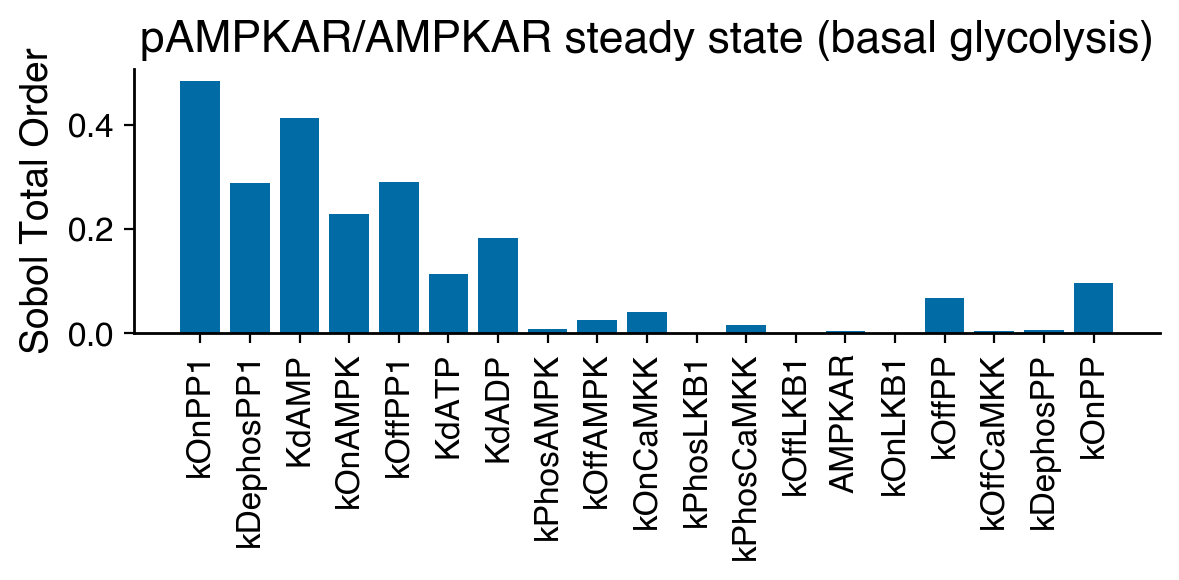

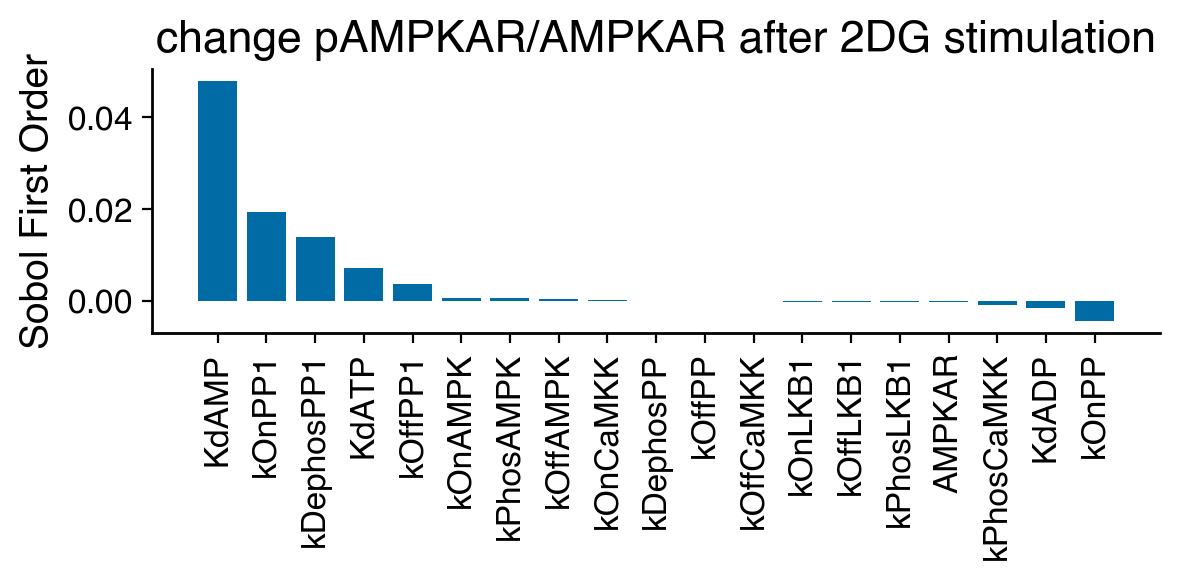

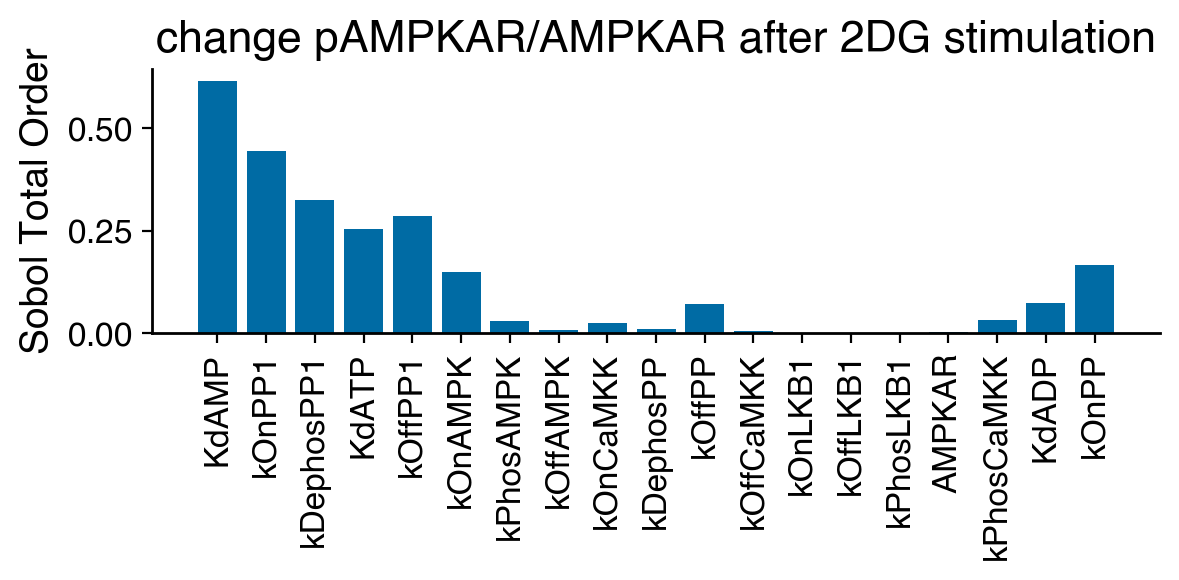

In [ ]:
fig, ax = plt.subplots(figsize=(6,3))
ax.bar(np.arange(0,19), Si_sobol_ss_sorted['S1'],
        # yerr=Si_sobol_ss_sorted['S1_conf'],
        log=False)
plt.xticks(np.arange(0,19), Si_sobol_ss_sorted['name'], rotation='vertical')
plt.ylabel('Sobol First Order')
plt.title('pAMPKAR/AMPKAR steady state (basal glycolysis)')
fig.savefig('./MA_double_mech/GSA_MA_double_mech_S1_ss.pdf')
plt.show()

fig, ax = plt.subplots(figsize=(6,3))
ax.bar(np.arange(0,19), Si_sobol_ss_sorted['ST'],
        # yerr=Si_sobol_ss_sorted['ST_conf'],
        log=False)
plt.xticks(np.arange(0,19), Si_sobol_ss_sorted['name'], rotation='vertical')
plt.ylabel('Sobol Total Order')
plt.title('pAMPKAR/AMPKAR steady state (basal glycolysis)')
fig.savefig('./MA_double_mech/GSA_MA_double_mech_ST_ss.pdf')
plt.show()

fig, ax = plt.subplots(figsize=(6,3))
ax.bar(np.arange(0,19), Si_sobol_delta_sorted['S1'],
        # yerr=Si_sobol_delta_sorted['S1_conf'],
        log=False)
plt.xticks(np.arange(0,19), Si_sobol_delta_sorted['name'], rotation='vertical')
plt.ylabel('Sobol First Order')
plt.title('change pAMPKAR/AMPKAR after 2DG stimulation')
fig.savefig('./MA_double_mech/GSA_MA_double_mech_S1_delta.pdf')
plt.show()

fig, ax = plt.subplots(figsize=(6,3))
ax.bar(np.arange(0,19), Si_sobol_delta_sorted['ST'],
        # yerr=Si_sobol_delta_sorted['ST_conf'],
        log=False)
plt.xticks(np.arange(0,19), Si_sobol_delta_sorted['name'], rotation='vertical')
plt.ylabel('Sobol Total Order')
plt.title('change pAMPKAR/AMPKAR after 2DG stimulation')
fig.savefig('./MA_double_mech/GSA_MA_double_mech_ST_delta.pdf')
plt.show()

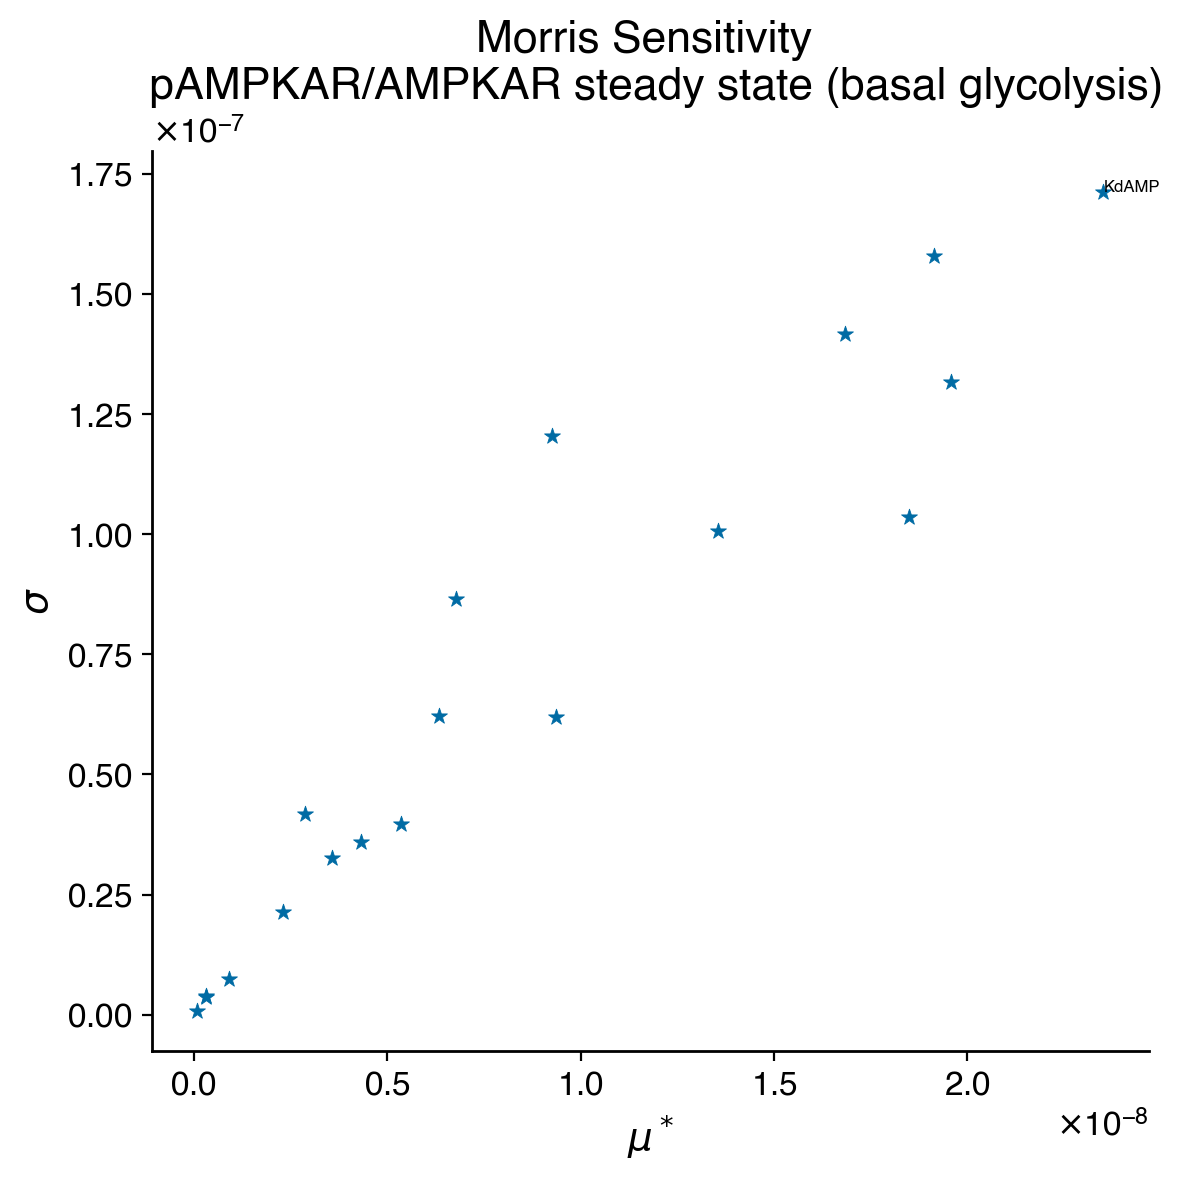

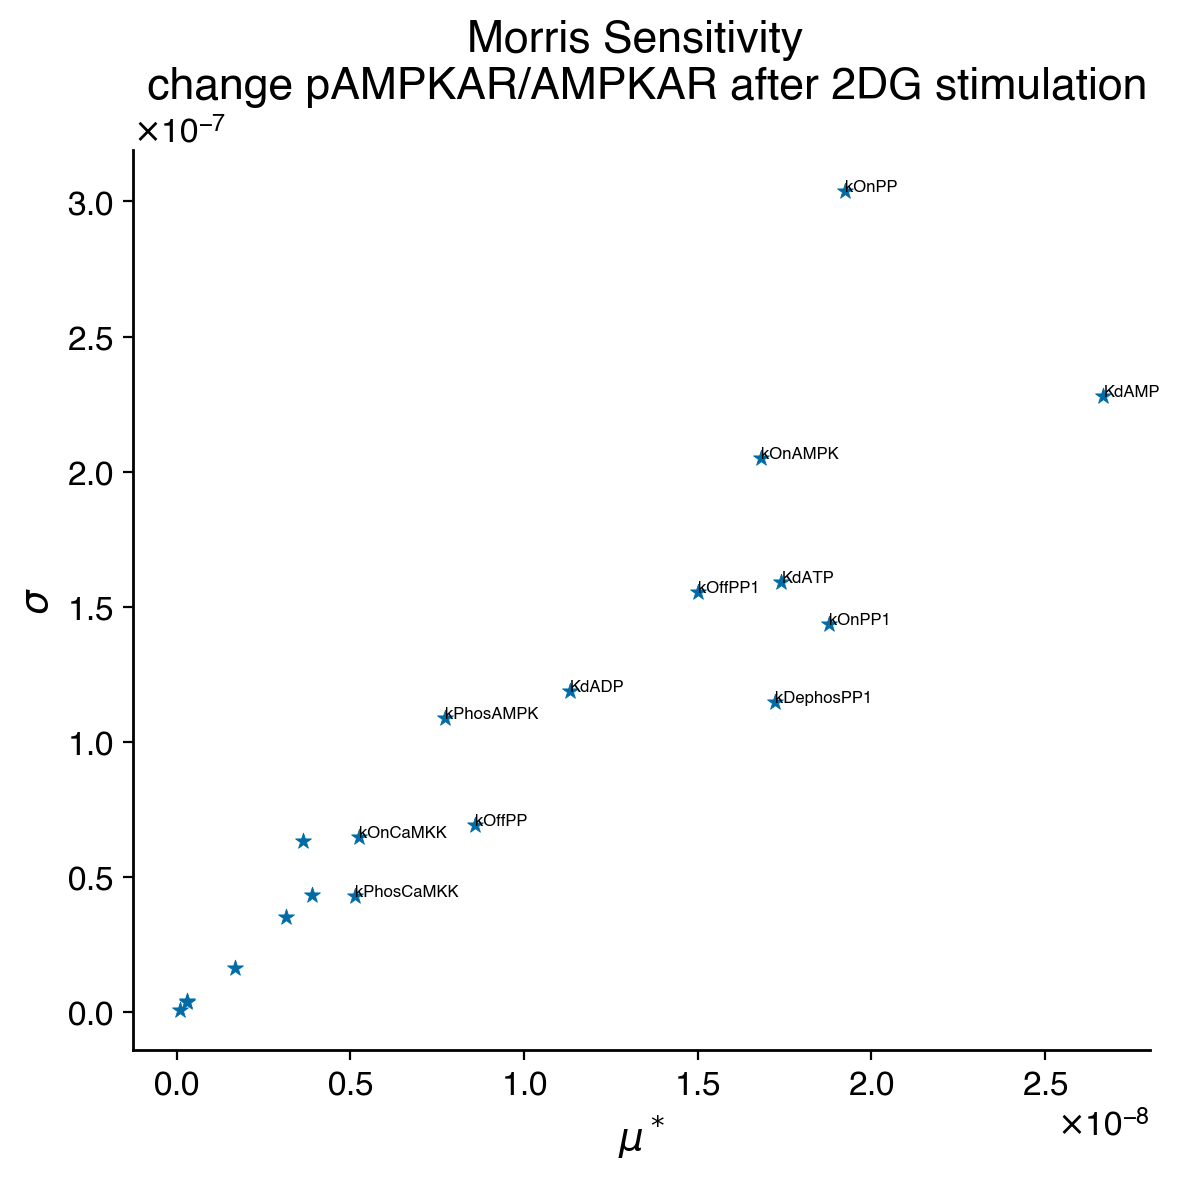

In [ ]:
fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(Si_morris_ss_sorted['mu_star'], Si_morris_ss_sorted['sigma'], marker='*',
           )
# ax.plot([0.05, 0.05], [0, 10], 'r', linewidth=1)
# ax.set_xscale('log')
# ax.set_yscale('log')

for i, name_mu_star in enumerate(zip(Si_morris_ss['names'], Si_morris_ss['mu_star'])):
    if name_mu_star[1] >= 2.0e-8:
        ax.annotate(name_mu_star[0], (name_mu_star[1], Si_morris_ss['sigma'][i]), fontsize=6)

ax.set_ylabel('$\sigma$')
ax.set_xlabel('$\mu^*$')
ax.set_title('Morris Sensitivity \n pAMPKAR/AMPKAR steady state (basal glycolysis)')
fig.savefig('./MA_double_mech/20230321_GSA_MA_double_mech_morris_ss.pdf')

fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(Si_morris_delta_sorted['mu_star'], Si_morris_delta_sorted['sigma'], marker='*',
           )
# ax.plot([0.05, 0.05], [0, 1e-10], 'r', linewidth=1)
# ax.set_xscale('log')
# ax.set_yscale('log')

for i, name_mu_star in enumerate(zip(Si_morris_delta['names'], Si_morris_delta['mu_star'])):
    if name_mu_star[1] >= 5.0e-9:
        ax.annotate(name_mu_star[0], (name_mu_star[1], Si_morris_delta['sigma'][i]), fontsize=6)

ax.set_ylabel('$\sigma$')
ax.set_xlabel('$\mu^*$')
ax.set_title('Morris Sensitivity \n change pAMPKAR/AMPKAR after 2DG stimulation')
fig.savefig('./MA_double_mech/20230321_GSA_MA_double_mech_morris_delta.pdf')
